# Car Price Prediction

Objective:
Predict used car price using machine learning.

Dataset:
Quikr Used Car Dataset

Target:
Price

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"data/quikr_car.csv")

In [3]:
df.head(10)

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel
5,Ford EcoSport Titanium 1.5L TDCi,Ford,2015,Ask For Price,"59,000 kms",Diesel
6,Ford Figo,Ford,2012,"1,75,000","41,000 kms",Diesel
7,Hyundai Eon,Hyundai,2013,"1,90,000","25,000 kms",Petrol
8,Ford EcoSport Ambiente 1.5L TDCi,Ford,2016,"8,30,000","24,530 kms",Diesel
9,Maruti Suzuki Alto K10 VXi AMT,Maruti,2015,"2,50,000","60,000 kms",Petrol


In [4]:
df.tail(10)

,name,company,year,Price,kms_driven,fuel_type
882,Maruti Suzuki Alto 800 Select Variant,Maruti,2015,Ask For Price,"70,000 kms",Petrol
883,Maruti Suzuki Ritz VXI ABS,Maruti,2011,"2,70,000","50,000 kms",Petrol
884,tata zest 2017 f,tata,sale,"4,50,000",NaN,NaN
885,Tata Indica V2 DLE BS III,Tata,2009,"1,10,000","30,000 kms",Diesel
886,Toyota Corolla Altis,Toyota,2009,"3,00,000","1,32,000 kms",Petrol
887,Ta,Tara,zest,"3,10,000",NaN,NaN
888,Tata Zest XM Diesel,Tata,2018,"2,60,000","27,000 kms",Diesel
889,Mahindra Quanto C8,Mahindra,2013,"3,90,000","40,000 kms",Diesel
890,Honda Amaze 1.2 E i VTEC,Honda,2014,"1,80,000",Petrol,NaN
891,Chevrolet Sail 1.2 LT ABS,Chevrolet,2014,"1,60,000",Petrol,NaN


In [5]:
df.shape


(892, 6)

In [6]:
df.columns

Index(['name', 'company', 'year', 'Price', 'kms_driven', 'fuel_type'], dtype='object')

In [7]:
df.dtypes

name          object
company       object
year          object
Price         object
kms_driven    object
fuel_type     object
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        892 non-null    object
 1   company     892 non-null    object
 2   year        892 non-null    object
 3   Price       892 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: object(6)
memory usage: 41.9+ KB


In [9]:
df.describe(include="all")


,name,company,year,Price,kms_driven,fuel_type
count,892,892,892,892,840,837
unique,525,48,61,274,258,3
top,Honda City,Maruti,2015,Ask For Price,"45,000 kms",Petrol
freq,13,235,117,35,30,440


In [10]:
df.sample(5)

,name,company,year,Price,kms_driven,fuel_type
169,Tata Indigo CS,Tata,2011,"85,000","11,400 kms",Diesel
726,Maruti Suzuki Swift Dzire Tour VDi,Maruti,2009,"2,50,000","51,000 kms",Diesel
523,Maruti Suzuki Eeco 5 STR WITH AC HTR,Maruti,2015,"2,78,000","39,000 kms",Petrol
48,Maruti Suzuki SX4 ZXI MT,Maruti,2010,"2,49,999","36,000 kms",Petrol
52,Mahindra Scorpio S10 4WD,Mahindra,2015,"2,50,000","48,508 kms",Diesel


In [11]:
df.isnull().sum()

name           0
company        0
year           0
Price          0
kms_driven    52
fuel_type     55
dtype: int64

In [12]:
df[df["kms_driven"].isnull()]

,name,company,year,Price,kms_driven,fuel_type
69,I want to sell my car Tata Zest,I,2017,Ask For Price,NaN,NaN
85,I want to sell my car Tata Zest,I,2017,Ask For Price,NaN,NaN
185,"Commercial , DZire LDI, 2016, for sale",Commercial,...,Ask For Price,NaN,NaN
195,"Tata indigo ecs LX, 201",Tata,150k,"1,50,000",NaN,NaN
206,MARUTI SUZUKI DESI,MARUTI,TOUR,"4,00,000",NaN,NaN
286,"Commercial , DZire LDI, 2016, for sale",Commercial,...,Ask For Price,NaN,NaN
294,Yama,Yamaha,r 15,"55,000",NaN,NaN
360,selling car Ta,selling,Zest,Ask For Price,NaN,NaN
368,Tata Zest 90,Tata,/-Rs,Ask For Price,NaN,NaN
385,Maruti Suzuki Swift Dzire car,Maruti,sale,"3,00,000",NaN,NaN


In [13]:
data = df.copy()

In [14]:
data.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


# **EDA**

## Price col cleaning

In [15]:
data["Price"].unique()

array(['80,000', '4,25,000', 'Ask For Price', '3,25,000', '5,75,000',
       '1,75,000', '1,90,000', '8,30,000', '2,50,000', '1,82,000',
       '3,15,000', '4,15,000', '3,20,000', '10,00,000', '5,00,000',
       '3,50,000', '1,60,000', '3,10,000', '75,000', '1,00,000',
       '2,90,000', '95,000', '1,80,000', '3,85,000', '1,05,000',
       '6,50,000', '6,89,999', '4,48,000', '5,49,000', '5,01,000',
       '4,89,999', '2,80,000', '3,49,999', '2,84,999', '3,45,000',
       '4,99,999', '2,35,000', '2,49,999', '14,75,000', '3,95,000',
       '2,20,000', '1,70,000', '85,000', '2,00,000', '5,70,000',
       '1,10,000', '4,48,999', '18,91,111', '1,59,500', '3,44,999',
       '4,49,999', '8,65,000', '6,99,000', '3,75,000', '2,24,999',
       '12,00,000', '1,95,000', '3,51,000', '2,40,000', '90,000',
       '1,55,000', '6,00,000', '1,89,500', '2,10,000', '3,90,000',
       '1,35,000', '16,00,000', '7,01,000', '2,65,000', '5,25,000',
       '3,72,000', '6,35,000', '5,50,000', '4,85,000', '3,29,5

In [16]:
"4,50,000".replace(",", "")

'450000'

In [17]:
data = data[data["Price"] != "Ask For Price"]

In [18]:
data.shape

(857, 6)

In [19]:
data["Price"] = data["Price"].str.replace(",", "")

In [20]:
data["Price"] = data["Price"].astype(int)

In [21]:
data["Price"].dtype

dtype('int64')

## Cleaning year Column

In [22]:
data["year"].unique()

array(['2007', '2006', '2014', '2012', '2013', '2016', '2015', '2010',
       '2017', '2008', '2018', '2011', '2019', '2009', '2005', '2000',
       '150k', 'TOUR', '2003', 'r 15', '2004', 'sale', '1995', 'ara)',
       '2002', 'SELL', '2001', 'tion', 'odel', '2 bs', 'arry', 'o...',
       'Zest', 'ture', 'emi', 'car', 'able', 'd...', 'SALE', 'sell',
       'd Ex', 'n...', 'e...', 'go .', 'k...', 'o c4', 'zire', 'Sumo',
       'cab', 'EV2', 'r...', 'zest'], dtype=object)

In [23]:
data["year"].str.isnumeric().value_counts()

year
True     819
False     38
Name: count, dtype: int64

In [24]:
data = data[data["year"].str.isnumeric()]

In [25]:
data["year"] = data["year"].astype(int)

In [26]:
data["year"].dtype

dtype('int64')

In [27]:
data.shape

(819, 6)

## Cleaning kms_driven

In [28]:
data["kms_driven"].unique()

array(['45,000 kms', '40 kms', '28,000 kms', '36,000 kms', '41,000 kms',
       '25,000 kms', '24,530 kms', '60,000 kms', '30,000 kms',
       '32,000 kms', '48,660 kms', '4,000 kms', '16,934 kms',
       '43,000 kms', '35,550 kms', '39,522 kms', '39,000 kms',
       '55,000 kms', '72,000 kms', '15,975 kms', '70,000 kms',
       '23,452 kms', '35,522 kms', '48,508 kms', '15,487 kms',
       '82,000 kms', '20,000 kms', '68,000 kms', '38,000 kms',
       '27,000 kms', '33,000 kms', '46,000 kms', '16,000 kms',
       '47,000 kms', '35,000 kms', '30,874 kms', '15,000 kms',
       '29,685 kms', '1,30,000 kms', '19,000 kms', '54,000 kms',
       '13,000 kms', '38,200 kms', '22,000 kms', '50,000 kms',
       '13,500 kms', '3,600 kms', '45,863 kms', '60,500 kms',
       '12,500 kms', '18,000 kms', '13,349 kms', '29,000 kms',
       '44,000 kms', '42,000 kms', '14,000 kms', '49,000 kms',
       '36,200 kms', '51,000 kms', '1,04,000 kms', '33,333 kms',
       '33,600 kms', '5,600 kms', '7,500 km

In [29]:
data["kms_driven"].isnull().sum()

np.int64(0)

In [30]:
data = data[data["kms_driven"].notnull()]

In [31]:
data.shape

(819, 6)

In [32]:
data["kms_driven"] = data["kms_driven"].str.replace(" kms","")

In [33]:
data["kms_driven"] = data["kms_driven"].str.replace(",","")

In [34]:
# data["kms_driven"] = data["kms_driven"].astype(int)

In [35]:
data["kms_driven"].dtype

dtype('O')

In [36]:
data[data["kms_driven"] == "Petrol"]

,name,company,year,Price,kms_driven,fuel_type
890,Honda Amaze 1.2 E i VTEC,Honda,2014,180000,Petrol,NaN
891,Chevrolet Sail 1.2 LT ABS,Chevrolet,2014,160000,Petrol,NaN


In [37]:
data[data["kms_driven"].str.contains("[A-Za-z]", regex=True, na=False)]

,name,company,year,Price,kms_driven,fuel_type
890,Honda Amaze 1.2 E i VTEC,Honda,2014,180000,Petrol,NaN
891,Chevrolet Sail 1.2 LT ABS,Chevrolet,2014,160000,Petrol,NaN


In [38]:
data = data[data["kms_driven"].str.contains("[A-Za-z]", regex=True) == False]

In [39]:
data["kms_driven"] = data["kms_driven"].str.replace(",", "")
data["kms_driven"] = data["kms_driven"].str.replace(" kms", "")
data["kms_driven"] = data["kms_driven"].astype(int)

In [40]:
data["kms_driven"] = data["kms_driven"].astype(int)

In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 817 entries, 0 to 889
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        817 non-null    object
 1   company     817 non-null    object
 2   year        817 non-null    int64 
 3   Price       817 non-null    int64 
 4   kms_driven  817 non-null    int64 
 5   fuel_type   816 non-null    object
dtypes: int64(3), object(3)
memory usage: 44.7+ KB


## Cleaning fuel_type

In [42]:
data = data[data["fuel_type"].notnull()]

In [43]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 816 entries, 0 to 889
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        816 non-null    object
 1   company     816 non-null    object
 2   year        816 non-null    int64 
 3   Price       816 non-null    int64 
 4   kms_driven  816 non-null    int64 
 5   fuel_type   816 non-null    object
dtypes: int64(3), object(3)
memory usage: 44.6+ KB


In [44]:
data.isnull().sum()

name          0
company       0
year          0
Price         0
kms_driven    0
fuel_type     0
dtype: int64

In [45]:
data["name"].head(10)

0       Hyundai Santro Xing XO eRLX Euro III
1                    Mahindra Jeep CL550 MDI
3     Hyundai Grand i10 Magna 1.2 Kappa VTVT
4           Ford EcoSport Titanium 1.5L TDCi
6                                  Ford Figo
7                                Hyundai Eon
8           Ford EcoSport Ambiente 1.5L TDCi
9             Maruti Suzuki Alto K10 VXi AMT
10               Skoda Fabia Classic 1.2 MPI
11                Maruti Suzuki Stingray VXi
Name: name, dtype: object

# **Feature Engineering**

In [46]:
data["model"] = data["name"].str.split(" ", n=1).str[1]

In [47]:
data[["company", "model"]].head(10)

,company,model
0,Hyundai,Santro Xing XO eRLX Euro III
1,Mahindra,Jeep CL550 MDI
3,Hyundai,Grand i10 Magna 1.2 Kappa VTVT
4,Ford,EcoSport Titanium 1.5L TDCi
6,Ford,Figo
7,Hyundai,Eon
8,Ford,EcoSport Ambiente 1.5L TDCi
9,Maruti,Suzuki Alto K10 VXi AMT
10,Skoda,Fabia Classic 1.2 MPI
11,Maruti,Suzuki Stingray VXi


In [48]:

data = data.drop(columns=["name"])

In [49]:
data.head()

,company,year,Price,kms_driven,fuel_type,model
0,Hyundai,2007,80000,45000,Petrol,Santro Xing XO eRLX Euro III
1,Mahindra,2006,425000,40,Diesel,Jeep CL550 MDI
3,Hyundai,2014,325000,28000,Petrol,Grand i10 Magna 1.2 Kappa VTVT
4,Ford,2014,575000,36000,Diesel,EcoSport Titanium 1.5L TDCi
6,Ford,2012,175000,41000,Diesel,Figo


In [50]:
data.shape


(816, 6)

In [51]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 816 entries, 0 to 889
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   company     816 non-null    object
 1   year        816 non-null    int64 
 2   Price       816 non-null    int64 
 3   kms_driven  816 non-null    int64 
 4   fuel_type   816 non-null    object
 5   model       816 non-null    object
dtypes: int64(3), object(3)
memory usage: 44.6+ KB


In [52]:
data.describe()

,year,Price,kms_driven
count,816.000000,8.160000e+02,816.000000
mean,2012.444853,4.117176e+05,46275.531863
std,4.002992,4.751844e+05,34297.428044
min,1995.000000,3.000000e+04,0.000000
25%,2010.000000,1.750000e+05,27000.000000
50%,2013.000000,2.999990e+05,41000.000000
75%,2015.000000,4.912500e+05,56818.500000
max,2019.000000,8.500003e+06,400000.000000


# Visualization 

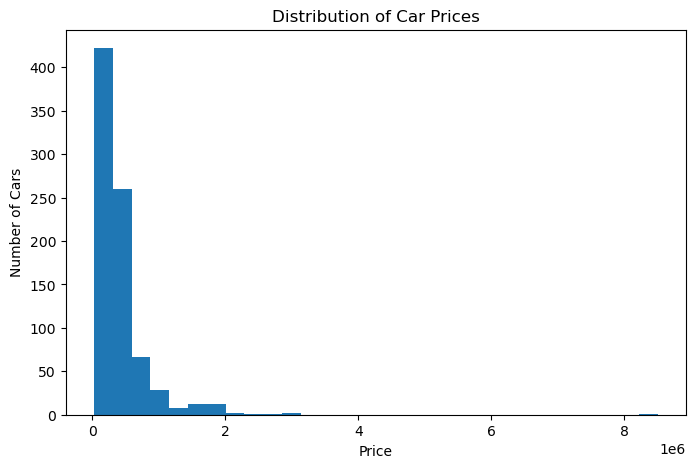

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(data["Price"], bins=30)
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Number of Cars")
plt.show()

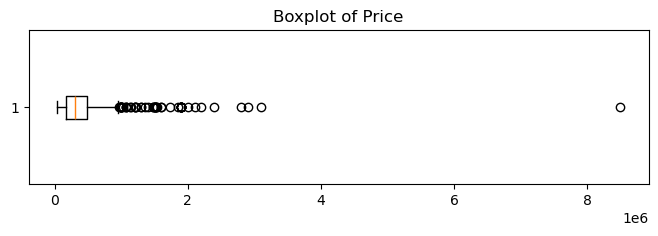

In [54]:
plt.figure(figsize=(8,2))
plt.boxplot(data["Price"], vert=False)
plt.title("Boxplot of Price")
plt.show()

In [55]:
data.sort_values(by="Price", ascending=False).head(10)

,company,year,Price,kms_driven,fuel_type,model
562,Mahindra,2014,8500003,45000,Diesel,XUV500 W6
719,Audi,2015,3100000,12516,Petrol,A3 Cabriolet 40 TFSI
838,Ford,2019,2900000,9000,Diesel,Endeavor 4x4 Thunder Plus
510,Jaguar,2016,2800000,8500,Petrol,XE XE Portfolio
668,Audi,2014,2390000,34000,Diesel,Q5 2.0 TDI quattro Premium Plus
667,Jaguar,2013,2190000,29000,Diesel,XF 2.2 Diesel Luxury
232,Land,2015,2100000,30000,Diesel,Rover Freelander 2 SE
231,Mercedes,2015,2000000,20000,Diesel,Benz GLA Class 200 CDI Sport
678,Audi,2016,1900000,44000,Diesel,A4 2.0 TDI 177bhp Premium
300,Mini,2013,1891111,13000,Petrol,Cooper S


In [56]:
data["Price"].max()

8500003

In [57]:
data = data[data["Price"] < 8000000]

In [58]:
data.shape

(815, 6)

In [59]:
data["company"].value_counts()

company
Maruti        221
Hyundai       139
Mahindra       97
Tata           65
Honda          60
Toyota         36
Chevrolet      34
Renault        33
Ford           30
Volkswagen     19
Skoda          13
Audi           11
Mini            8
BMW             8
Datsun          7
Mitsubishi      6
Nissan          6
Mercedes        6
Fiat            4
Force           4
Hindustan       3
Jaguar          2
Land            1
Jeep            1
Volvo           1
Name: count, dtype: int64

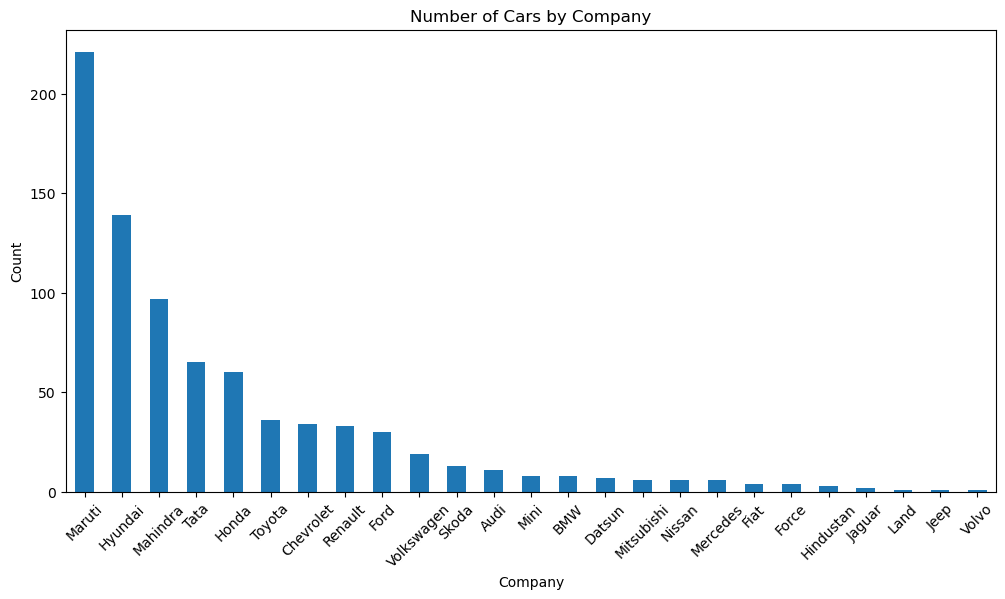

In [60]:
plt.figure(figsize=(12,6))

data["company"].value_counts().plot(kind="bar")

plt.title("Number of Cars by Company")
plt.xlabel("Company")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [61]:
data.groupby("company")["Price"].mean().sort_values(ascending=False)

company
Jaguar        2.495000e+06
Land          2.100000e+06
Mini          1.891111e+06
Volvo         1.850000e+06
Audi          1.476909e+06
Mitsubishi    1.298333e+06
Mercedes      1.170667e+06
BMW           1.049875e+06
Jeep          9.500000e+05
Force         5.725000e+05
Toyota        5.244443e+05
Mahindra      5.220288e+05
Ford          4.797999e+05
Nissan        4.606663e+05
Renault       4.605123e+05
Volkswagen    4.071050e+05
Honda         3.476329e+05
Hyundai       3.184028e+05
Hindustan     3.033333e+05
Maruti        2.698376e+05
Datsun        2.557140e+05
Skoda         2.511914e+05
Chevrolet     2.020853e+05
Tata          2.009393e+05
Fiat          1.098750e+05
Name: Price, dtype: float64

In [62]:
data["fuel_type"].value_counts()

fuel_type
Petrol    428
Diesel    385
LPG         2
Name: count, dtype: int64

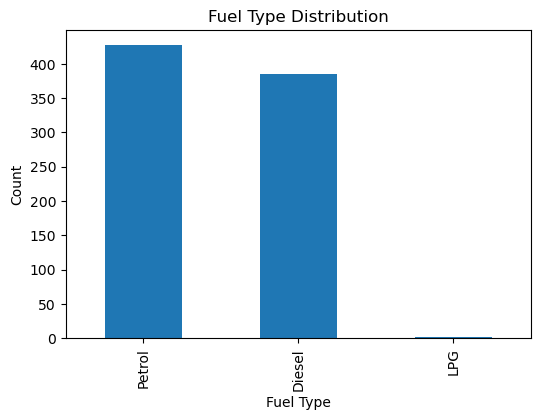

In [63]:
plt.figure(figsize=(6,4))

data["fuel_type"].value_counts().plot(kind="bar")

plt.title("Fuel Type Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Count")

plt.show()

In [64]:
data.groupby("fuel_type")["Price"].mean()

fuel_type
Diesel    489095.740260
LPG       205000.000000
Petrol    324181.567757
Name: Price, dtype: float64

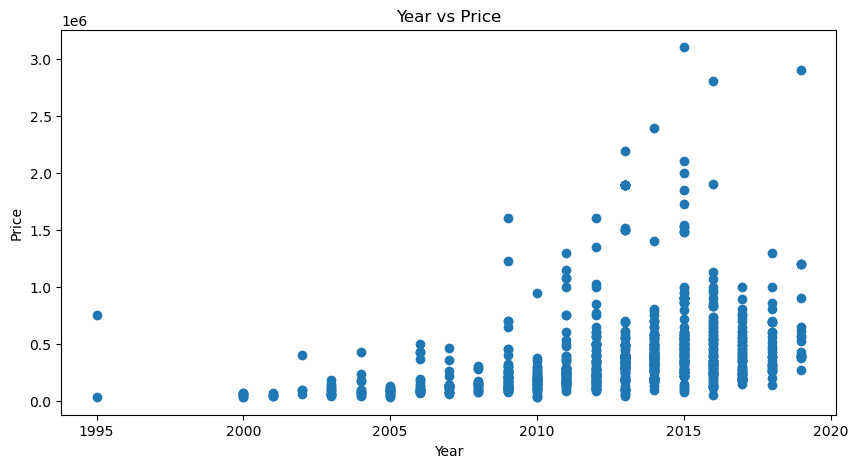

In [65]:
plt.figure(figsize=(10,5))

plt.scatter(data["year"], data["Price"])

plt.title("Year vs Price")
plt.xlabel("Year")
plt.ylabel("Price")

plt.show()

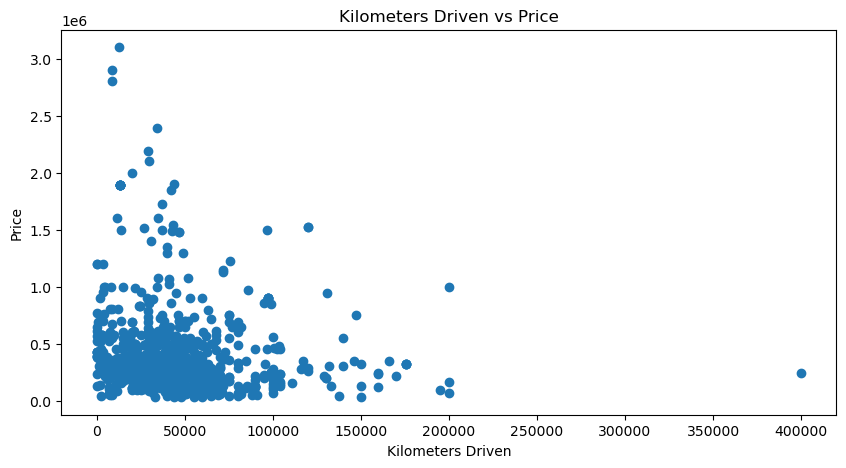

In [66]:
plt.figure(figsize=(10,5))

plt.scatter(data["kms_driven"], data["Price"])

plt.title("Kilometers Driven vs Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Price")

plt.show()

<Figure size 1400x600 with 0 Axes>

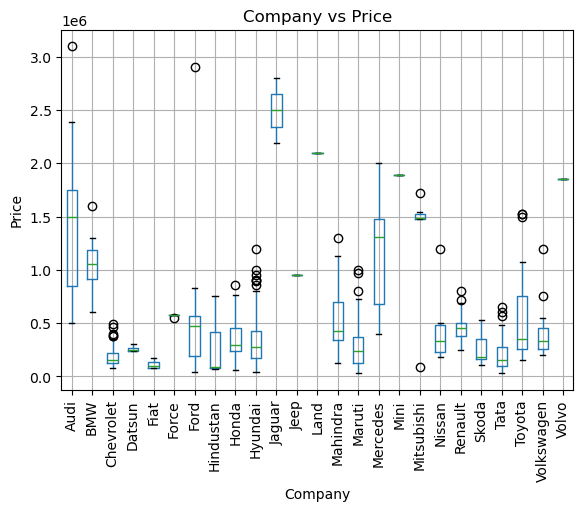

In [67]:
plt.figure(figsize=(14,6))

data.boxplot(column="Price", by="company", rot=90)

plt.title("Company vs Price")
plt.suptitle("")   # Removes extra title
plt.xlabel("Company")
plt.ylabel("Price")

plt.show()

<Figure size 600x500 with 0 Axes>

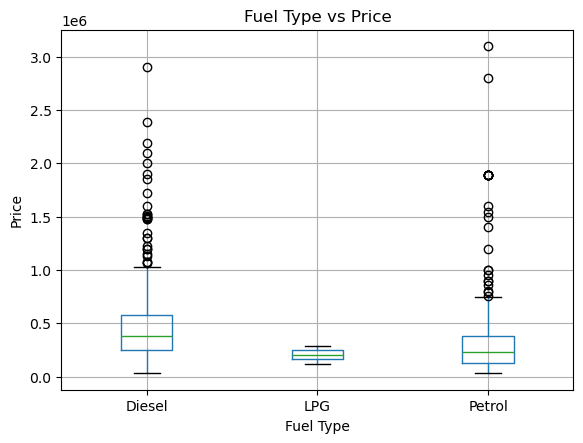

In [68]:
plt.figure(figsize=(6,5))

data.boxplot(column="Price", by="fuel_type")

plt.title("Fuel Type vs Price")
plt.suptitle("")
plt.xlabel("Fuel Type")
plt.ylabel("Price")

plt.show()

# Cleaned Data Saveing 

In [69]:
# data.to_csv("Data/cleaned_car_data.csv", index=False)

# **ML - Feature Selection**

In [70]:
X = data.drop("Price", axis=1)

y = data["Price"]

print(X.head())
print()
print(y.head())
print()
print(X.shape)
print(y.shape)

    company  year  kms_driven fuel_type                           model
0   Hyundai  2007       45000    Petrol    Santro Xing XO eRLX Euro III
1  Mahindra  2006          40    Diesel                  Jeep CL550 MDI
3   Hyundai  2014       28000    Petrol  Grand i10 Magna 1.2 Kappa VTVT
4      Ford  2014       36000    Diesel     EcoSport Titanium 1.5L TDCi
6      Ford  2012       41000    Diesel                            Figo

0     80000
1    425000
3    325000
4    575000
6    175000
Name: Price, dtype: int64

(815, 5)
(815,)


In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (652, 5)
X_test  : (163, 5)
y_train : (652,)
y_test  : (163,)


In [72]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [73]:
categorical_features = ["company", "fuel_type", "model"]

numeric_features = ["year", "kms_driven"]

In [74]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

In [75]:
preprocessor

,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


In [76]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [77]:
pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [78]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [79]:
y_pred = pipeline.predict(X_test)

print(y_pred[:10])

[ 76281.74199211 404473.81641363 392358.26379885 440547.14102168
 457089.14923436 434265.82682124 151312.6424353  232210.79794976
 457209.19932619 224308.54692769]


In [80]:
comparison = X_test.copy()

comparison["Actual Price"] = y_test.values
comparison["Predicted Price"] = y_pred.astype(int)

comparison.head(10)

,company,year,kms_driven,fuel_type,model,Actual Price,Predicted Price
204,Maruti,2006,45000,Petrol,Suzuki Swift VXI BSIII,135000,76281
312,Honda,2011,55000,Petrol,City,284999,404473
407,Volkswagen,2011,65000,Diesel,Vento Konekt Diesel Highline,245000,392358
236,Datsun,2016,7000,Petrol,GO T O,245000,440547
706,Maruti,2016,51000,Diesel,Suzuki Swift Dzire VDi,499000,457089
873,Maruti,2016,150000,Diesel,Suzuki Dzire,325000,434265
208,Maruti,2010,34580,Petrol,Suzuki Alto LXi BS III,135000,151312
349,Hyundai,2014,14000,Petrol,Eon,174999,232210
351,Hyundai,2015,35000,Diesel,i20 Active,574999,457209
555,Hyundai,2010,10750,Petrol,i20 Asta 1.2,300000,224308


In [81]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 2))
print("MSE :", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 4))

MAE : 153105.91
MSE : 88004647302.5
RMSE: 296655.77
R2 Score: 0.5678


# **Now...there Linear Regressor model is failed...because** 

**Reason 1: Linear Regression assumes a linear relationship.**

It assumes:

Year ↑  → Price ↑ (Straight Line)

KM ↑    → Price ↓ (Straight Line)

But in reality:

Luxury brands behave differently.
Some models hold their value much better.
Price doesn't always change in a straight line.

========================================================================

**Reason 2: Company and Model**

Look at these predictions:

Actual	Predicted
135000	76281
245000	440547

The model makes some large errors.

Why?

Because model names like:

Swift Dzire
City
EcoSport
Creta

have very different resale values.

Linear Regression struggles to capture these complex relationships.

============================================================================================================

**Reason 3: Outliers**

Even after removing the ₹85 lakh Mahindra, there are still very expensive luxury cars like:

Audi
BMW
Jaguar
Mercedes

These influence the regression line.

# **Next Model: Decision Tree Regressor**

In [82]:
from sklearn.tree import DecisionTreeRegressor

In [83]:
dt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(random_state=42))
    ]
)

In [84]:
dt_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [85]:
dt_pred = dt_pipeline.predict(X_test)

In [86]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, dt_pred)
rmse = mean_squared_error(y_test, dt_pred) ** 0.5
r2 = r2_score(y_test, dt_pred)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R2 Score:", round(r2,4))

MAE : 138438.09
RMSE: 331440.43
R2 Score: 0.4606


**DT-ML-Model  also failed...because**

MAE improved, but R² became worse?

Yes!

This is why we never judge a model using only one metric.

# **Next Model  is (Random Forest)**

In [87]:
from sklearn.ensemble import RandomForestRegressor

In [88]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

In [89]:
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [90]:
rf_pred = rf_pipeline.predict(X_test)

In [91]:
mae = mean_absolute_error(y_test, rf_pred)
rmse = mean_squared_error(y_test, rf_pred) ** 0.5
r2 = r2_score(y_test, rf_pred)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R2 :", round(r2,4))

MAE : 133302.35
RMSE: 307953.29
R2 : 0.5343


In [100]:
# Predict on test data
rf_pred = rf_pipeline.predict(X_test)

print("Actual Prices")
print(y_test.head())

print("\nPredicted Prices")
print(rf_pred[:10])

Actual Prices
204    135000
312    284999
407    245000
236    245000
706    499000
Name: Price, dtype: int64

Predicted Prices
[ 97115.93833333 330929.34       249472.37       275914.72
 419995.39       372477.44       161639.925      305619.915
 490572.46       134039.975     ]


In [93]:
rf_pipeline.named_steps["model"].feature_importances_


array([1.28173080e-01, 3.32170564e-02, 4.06890043e-03, 5.79328032e-04,
       1.14417300e-04, 1.90147645e-04, 3.14182151e-03, 5.92454591e-04,
       1.68747026e-03, 2.12437040e-03, 1.50718807e-02, 7.69113757e-04,
       1.81107535e-02, 2.05062910e-02, 3.01904214e-03, 3.53062636e-02,
       1.22678042e-01, 5.85098440e-02, 5.82745768e-04, 3.50860560e-03,
       4.92058704e-04, 1.35110382e-02, 8.87855258e-03, 1.22049726e-03,
       2.17726526e-02, 1.85523914e-05, 7.42534595e-03, 1.18325253e-04,
       4.02211999e-04, 3.53935865e-04, 1.27341558e-03, 3.79549514e-02,
       2.42526481e-03, 7.33012495e-03, 2.03640300e-03, 9.47166545e-04,
       3.23529613e-05, 1.18565165e-05, 2.56291069e-07, 2.12359665e-07,
       3.57097303e-04, 4.36640747e-05, 3.76706052e-06, 3.25997364e-06,
       9.93130425e-05, 2.12853135e-04, 7.32388104e-05, 1.27127120e-04,
       3.59710829e-04, 6.97838953e-05, 6.23445294e-04, 9.77630489e-06,
       2.19128360e-05, 3.15066947e-05, 2.54523864e-03, 4.64153658e-04,
      

In [94]:
y_test   # Actual prices


204    135000
312    284999
407    245000
236    245000
706    499000
        ...  
665    179999
666    140000
827    425000
546    110000
707     85000
Name: Price, Length: 163, dtype: int64

In [95]:
rf_pred  # Predicted prices

array([  97115.93833333,  330929.34      ,  249472.37      ,
        275914.72      ,  419995.39      ,  372477.44      ,
        161639.925     ,  305619.915     ,  490572.46      ,
        134039.975     ,  310206.07      ,  124945.015     ,
        482749.955     ,   98224.99      , 1882580.445     ,
        334604.98      ,  534964.18      ,  309226.16      ,
        838469.7       ,  266468.36      ,  334434.695     ,
        130457.475     ,  458657.475     ,  776064.805     ,
        227079.765     ,  216564.93      ,  416336.64166667,
        584919.955     ,  267892.92      ,  646017.355     ,
        434690.        ,  345149.59      ,   93574.855     ,
        111294.985     ,  413136.975     ,  114699.97      ,
        453744.935     ,  682984.955     ,  413116.49      ,
        705079.225     ,  181289.96      ,  310566.59      ,
         70045.80333333,  395513.82166667,  345359.025     ,
        241954.995     ,  416765.445     ,   45119.65      ,
        184055.535     ,

# Model Saveing & Testing 

In [96]:
import joblib

#joblib.dump(pipeline, "car_price_prediction_pipeline_1.joblib")

In [97]:
loaded_model = joblib.load("car_price_prediction_pipeline_1.joblib")

In [98]:
import pandas as pd

sample_car = pd.DataFrame({
    "company": ["Hyundai"],
    "year": [2018],
    "kms_driven": [45000],
    "fuel_type": ["Petrol"],
    "model": ["Grand i10 Magna 1.2 Kappa VTVT"]
})

In [99]:
prediction = loaded_model.predict(sample_car)

print("Predicted Price:", int(prediction[0]))

Predicted Price: 418566
